# Notebook consacré à l'analyse des questions relatives à la Science Ouverte

In [118]:
import pandas as pd

import os #pour naviguer dans les dossiers
from io import StringIO
import s3fs #pour connecter au bucket
import scipy.stats

import seaborn as sns
import matplotlib.pyplot as plt

In [119]:


# Create filesystem object
S3_ENDPOINT_URL = "https://" + os.environ["AWS_S3_ENDPOINT"]
fs = s3fs.S3FileSystem(client_kwargs={'endpoint_url': S3_ENDPOINT_URL})

BUCKET_OUT = "aluneau"



In [120]:
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/anonymous_answer_2026-05-11.csv", "r") as file_in:
    df0 = pd.read_csv(file_in, sep =",")


df_col = pd.read_csv("../le_questionnaire/dico_variable.csv", sep = ",")
list_affil = pd.read_csv("list_affiliation.csv", sep =",")
df0 = df0.loc[~df0.q45_clé.isin(["9EAP-NB4B","QNYZ-3MH2"])].merge(list_affil, on = ["q45_clé", "q44_ufr_labo"], how = "left")

In [4]:
list_nominal_simple = [x for x in df_col.label.loc[(df_col.type.isin(["simple_nominal", "booléen","ordinal"]))]]


In [5]:
def split_multiple_choices(data, column, index, sep = '|'):
    """
    split and explode column with multiple value

    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_split = data.copy()
    df_split[column]= df_split.apply(lambda row: row[column].replace(";","|") ,1 )
    df_split[column] = df_split[column].str.split(sep)
    df_explode = df_split.explode(column)
    gb_data = df_explode.groupby([column]).agg(nb = (index, "size")).sort_values("nb", ascending=False).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100
    
    return df_explode, gb_data
    

In [6]:
def grouped_question(data, column, index = "q45_clé"):
    """
    split and explode column with multiple value

    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_tmp = data.copy()
    gb_data = df_tmp.groupby([column]).agg(nb = (index, "size")).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100

    return gb_data

In [7]:
df0

,qno_obs,q1_so_principles,q2_hal_depot,q3_octavi_depot,q4_diff_data,q4_autres_entrepots,q5_r,q5_python,q5_excel,q5_julia,...,q25_doctorant,q3_octavi_rec,q4_autres_entrepots_rec,q4_diff_data_grouped,q4_diff_data_rec,q6_1_rec_exemple,q6_1_rec_groupe,q6_1_rec_how,q5_1_other_lang_rec,q5_1_other_lang_family
0,1,"Oui, un peu","Oui, une fois",Non,Non,NaN,Non,Non,Non,Non,...,True,Non,NaN,Non,Non,NaN,NaN,NaN,NaN,NaN
1,2,"Oui, un peu","Oui, une fois",Non,Non,NaN,Non,Non,Non,Non,...,False,Non,NaN,Non,Non,NaN,NaN,NaN,NaN,NaN
2,3,"Oui, tout à fait","Oui, plusieurs fois",Je ne connais pas Octaviana,Non,NaN,Non,Non,Oui,Non,...,False,Non,NaN,Non,Non,NaN,NaN,NaN,maxqda|endnotes|zotero,NaN
3,4,"Oui, un peu","Oui, une fois",Non,"Autre, précisez",OSF,Oui,Non,Non,Non,...,False,Non,osf,Oui,osf,NaN,NaN,NaN,NaN,NaN
4,6,"Oui, un peu","Oui, systématiquement",Non;Je ne connais pas Octaviana,Non,NaN,Oui,Non,Oui,Non,...,False,Non,NaN,Non,Non,NaN,NaN,NaN,​-,​-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,115,"Oui, tout à fait","Oui, plusieurs fois",Non,"Autre, précisez",osf,Oui,Oui,Non,Non,...,False,Non,osf,Oui,osf,NaN,NaN,NaN,mplus|spss,mplus|logiciels statistiques
113,116,"Oui, tout à fait","Oui, plusieurs fois",Non,"Oui, sur Zenodo, Nakala",NaN,Non,Non,Oui,Non,...,False,Non,NaN,Oui,"Oui, sur Zenodo, Nakala",base de données,traitement et analyse de données,NaN,NaN,NaN
114,117,"Oui, un peu","Oui, plusieurs fois",Non,"Autre, précisez",OSF,Oui,Oui,Oui,Non,...,True,Non,osf,Oui,osf,NaN,NaN,NaN,NaN,NaN
115,118,"Oui, un peu","Oui, systématiquement",Non,Non,NaN,Oui,Non,Oui,Non,...,False,Non,NaN,Non,Non,NaN,NaN,NaN,NaN,NaN


In [8]:
df_col["question_family"] = df_col.label.apply(lambda row : row.split("_")[0])

dict_question = dict(zip(df_col.label.loc[df_col.label.isin(list_nominal_simple)], df_col.question_family.loc[df_col.label.isin(list_nominal_simple)]))


# Les principes de la Science Ouverte et sa pratique

Plusieurs questions de l'enquête portent sur les connaissances et les pratiques de la Science Ouverte. La première question demande ainsi aux participants s'ils "sont "familiers des principes de la Science Ouverte". 57% ont répond "oui, un peu", 32 "oui, tout à fait" et 10% "non". Ils sont par ailleurs 40% à avoir déposé plusieurs fois des publications sur Hal, et 35% le font systématiquement. 

| Principes de la science ouverte   |   nb |    freq | 
|:-------------------|-----:|--------:|
| Non                |   12 |    10.3 | 
| Oui, tout à fait   |   38 |    32.5 |
| Oui, un peu        |   67 |    57.3 |
|                    |  117 |   100.0 |


| q2_hal_depot          |   nb |   total |    freq |
|:----------------------|-----:|--------:|--------:|
| Non                   |   15 |     117 | 12.8 | 
| Oui, plusieurs fois   |   47 |     117 | 40.2 |
| Oui, systématiquement |   41 |     117 | 35.0 |   
| Oui, une fois         |   14 |     117 | 12.0 |   

|q4_diff_data            |   nb |   total |      freq |  
|---:|-----:|--------:|----------:|
| Autre, précisez         |   25 |     117 | 21.4  |   
| Non                     |   84 |     117 | 71.8  |  
| Oui, sur Data Paris 8   |    1 |     117 |  0.9 |  
| Oui, sur Nakala         |    3 |     117 |  2.6   |   
| Oui, sur Zenodo, Nakala |    4 |     117 |  3.5   | 

En ce qui concerne l'ouverture des données, 72% des personnes interrogées ne l'ont jamais fait. ParmiScience les 28% personnes restantes, 6% d'entre elles ont utilisé au moins une fois des entrepôts généralistes comme Data Paris 8 et Nakala ont été utilisés. parmi les autres moyens de diffusion utilisés, 10 personnes utilisent Open Science Framework (OSF), six mettent leurs données sur le site web personnel et trois les entreposent sur un dépôt "git". On observe également que trois répondants déposent leurs données sur les entrepots spécialisés, liés à la linguistiques, Ortolang et Cocoon.

![](viz/autre_entrepot_rec.png)

Enfin, un peu moins de 10% des personnes interrogées ont déjà déposé des productions sur Octaviana. Ces productions sont des captations d'événements pour trois d'entre elles et des travaux universitaires et des publications pour les huit autres. Par ailleurs seules neuf personnes sur les 91 n'ayant jamais déposé de production sur Octaviana ont précisé qu'elles ne connaissaient pas la bibliothèque numérique. En tout une personne sur cinq n'en a jamais entendu parlé.


In [13]:
so_principe = grouped_question(df0, column="q1_so_principles", index = "q45_clé")
print(so_principe)
depot_hal = grouped_question(df0, column="q2_hal_depot", index = "q45_clé")
print("\n### Dépôt dans hal\n", depot_hal)
octaviana = grouped_question(df0, column="q3_octavi_rec", index = "q45_clé")
print("\n### Dépôt dans Octaviana\n", octaviana)

df_exp, octaviana2 = split_multiple_choices(df0, column="q3_octavi_depot", index="q45_clé", sep = '|')
print("\n### Dépôt dans Octaviana détaillé \n", octaviana2.to_markdown())



   q1_so_principles  nb  total       freq  total_freq
0               Non  12    117  10.256410       100.0
1  Oui, tout à fait  38    117  32.478632       100.0
2       Oui, un peu  67    117  57.264957       100.0

### Dépôt dans hal
             q2_hal_depot  nb  total       freq  total_freq
0                    Non  15    117  12.820513       100.0
1    Oui, plusieurs fois  47    117  40.170940       100.0
2  Oui, systématiquement  41    117  35.042735       100.0
3          Oui, une fois  14    117  11.965812       100.0

### Dépôt dans Octaviana
   q3_octavi_rec   nb  total       freq  total_freq
0           Non  106    117  90.598291       100.0
1           Oui   11    117   9.401709       100.0

### Dépôt dans Octaviana détaillé 
 |    | q3_octavi_depot                                         |   nb |   total |    freq |   total_freq |
|---:|:--------------------------------------------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                           

In [14]:
df0.loc[df0.q4_diff_data !="Non", "q4_diff_data_grouped"] = "Oui"
df0.loc[df0.q4_diff_data =="Non", "q4_diff_data_grouped"] = "Non"

depot_donnee = grouped_question(df0, column="q4_diff_data_grouped", index = "q45_clé")
print("\n### Dépôt des données de recherche\n", depot_donnee)

df_exp, depot_donnee2 = split_multiple_choices(df0, column="q4_diff_data", index="q45_clé", sep = '|')
print("\n### Dépôt dans Octaviana détaillé \n", depot_donnee2.to_markdown(index=False))


### Dépôt des données de recherche
   q4_diff_data_grouped  nb  total       freq  total_freq
0                  Non  84    117  71.794872       100.0
1                  Oui  33    117  28.205128       100.0

### Dépôt dans Octaviana détaillé 
 | q4_diff_data            |   nb |   total |      freq |   total_freq |
|:------------------------|-----:|--------:|----------:|-------------:|
| Non                     |   84 |     117 | 71.7949   |          100 |
| Autre, précisez         |   25 |     117 | 21.3675   |          100 |
| Oui, sur Zenodo, Nakala |    4 |     117 |  3.4188   |          100 |
| Oui, sur Nakala         |    3 |     117 |  2.5641   |          100 |
| Oui, sur Data Paris 8   |    1 |     117 |  0.854701 |          100 |


## Les autres modes de dépôt des données de recherche

In [11]:
df0.loc[df0["q4_diff_data"]=='Autre, précisez', "q4_diff_data_rec"] = df0.q4_autres_entrepots_rec
df0.loc[df0["q4_diff_data"]!='Autre, précisez', "q4_diff_data_rec"] = df0.q4_diff_data
df0.loc[df0["q4_diff_data_rec"].isna(), "q4_diff_data_rec"] = "NSP"
q4 = split_multiple_choices(df0, column="q4_diff_data_rec", index="q45_clé", sep = '|')

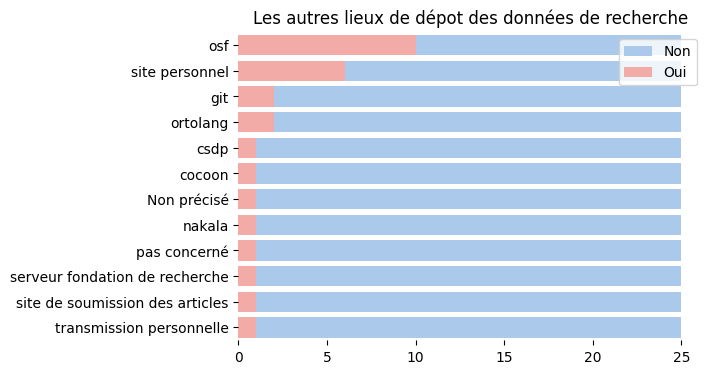

In [12]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,4))

# Plot the total crashes
sns.set_color_codes("pastel")
q4_other = df0.loc[df0.q4_diff_data=="Autre, précisez"].fillna("Non précisé")
col= "q4_autres_entrepots_rec"
df_exp, gb_data = split_multiple_choices(q4_other, column=col, index="q45_clé", sep = '|')
sns.barplot(x="total", y=col, data=gb_data,
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_data,
            label="Oui", color="r", ax=ax)
titre = "Les autres lieux de dépot des données de recherche"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
plt.savefig(f"viz/autre_entrepot_rec.png", bbox_inches='tight', dpi = 200)

## Production et analyse des données

### Types de données produites

Les personnes interrogées travaillant exclusivement avec des données dites "quantitatives" sont minoritaires, près de la moitié s'appuient essentiellement sur des données qualitatives et environ un tiers manipulent les deux types de données.

| q11_quali_or_quanti       |   nb |    freq |
|:--------------------------|-----:|--------:|
| Des données qualitatives  |   56 | 47.9 |
| Des données quantitatives |   19 | 16.2 |
| Les deux                  |   42 | 35.9 |
|Total                      |  117 |100.0 |

Les quatre types de données les plus fréquemment produites sont les entretiens, les données textuelles, les données d'enquête et les données expérimentales ou d'observation. On notera toutefois le caractère ambigü de certaines catégories. Ainsi la notion d'"enquête" est largement utilisé en sciences sociales pour désigner la partie empirique des recherche et renvoie aussi bien aux méthodes d'enquêtes ethnographiques qu'aux méthodes d'enquêtes par questionnaire. De même, les données d'observation peuvent se comprendre au sens de l'anthropologue qui observe les interactions au sein d'un groupe humain ou de l'ornithologue qui compte les espèces d'oiseau. Parmi les "autres types de données", une personne a d'ailleurs précisé qu'il s'agissait d "observations in situ non expérimentales". Tandis qu'une autre ne se reconnait pas dans la notion de "donnée".



![](viz/type_donnee_quali.png)



In [15]:
quali_or_quanti = grouped_question(df0, column="q11_quali_or_quanti", index = "q45_clé")
print(quali_or_quanti[["q11_quali_or_quanti","nb","freq"]].to_markdown(index=False))


df_exp, type_data = split_multiple_choices(df0, column="q10_type_data", index="q45_clé", sep = '|')
print("\n### Dépôt dans Octaviana détaillé \n", type_data.to_markdown())

| q11_quali_or_quanti       |   nb |    freq |
|:--------------------------|-----:|--------:|
| Des données qualitatives  |   56 | 47.8632 |
| Des données quantitatives |   19 | 16.2393 |
| Les deux                  |   42 | 35.8974 |

### Dépôt dans Octaviana détaillé 
 |    | q10_type_data                           |   nb |   total |    freq |   total_freq |
|---:|:----------------------------------------|-----:|--------:|--------:|-------------:|
|  0 | Données d'entretien                     |   73 |     117 | 62.3932 |          100 |
|  1 | Données textuelles ou documentaires     |   67 |     117 | 57.265  |          100 |
|  2 | Données d'enquête                       |   62 |     117 | 52.9915 |          100 |
|  3 | Données expérimentales ou d'observation |   60 |     117 | 51.2821 |          100 |
|  4 | Données statistiques                    |   46 |     117 | 39.3162 |          100 |
|  5 | Métadonnées                             |   22 |     117 | 18.8034 |          100 |


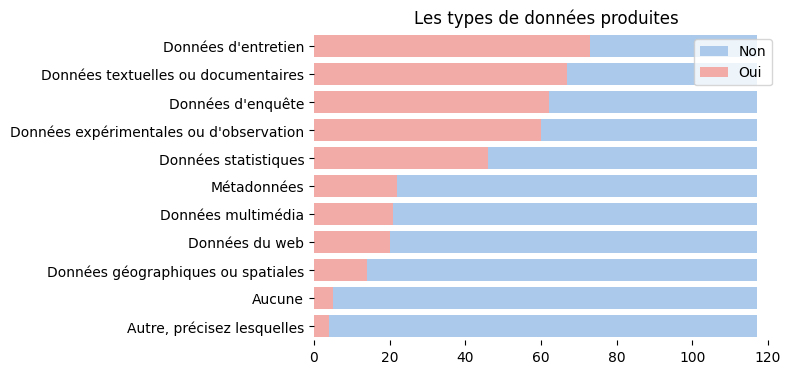

In [16]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,4))

# Plot the total crashes
sns.set_color_codes("pastel")

col= "q10_type_data"
df_exp, gb_data = split_multiple_choices(df0, column=col, index="q45_clé", sep = '|')
sns.barplot(x="total", y=col, data=gb_data,
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_data,
            label="Oui", color="r", ax=ax)
titre = "Les types de données produites"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
plt.savefig(f"viz/type_donnee.png", bbox_inches='tight', dpi = 200)

In [17]:
def tab_croise(data, x, y, regroup_y = True, khideux = False) :
    """
    x = variable en ligne
    y = variable en colonne
    """
    if regroup_y == True:

        data.loc[data[y].str.lower().str.contains("oui"), f"{y}_rec"] = "Oui"
        data.loc[data[y].str.lower().str.contains("non"), f"{y}_rec"] = "Non"

        cross_tab = pd.crosstab(data[x], data[f"{y}_rec"], margins = True, margins_name="Total", normalize=False)
        cross_tab0 = pd.crosstab(data[x], data[f"{y}_rec"], margins = False)
    else:
        cross_tab = pd.crosstab(data[x], data[y], margins = True, margins_name="Total", normalize=False)
        cross_tab0 = pd.crosstab(data[x], data[y], margins = False, normalize=False)

    if khideux == True:
        print(scipy.stats.chi2_contingency(cross_tab0))
        st_chi2, st_p, st_dof, st_exp = scipy.stats.chi2_contingency(cross_tab0)
        chi2 = pd.DataFrame(data={"stats":["chi2","df","p-value"], "values":[st_chi2, st_dof, st_p]})
        cross_tab = pd.concat([cross_tab, chi2])
    else:
        pass

    return cross_tab.fillna("").reset_index(), cross_tab0

In [18]:
col= "q10_type_data"
df_exp, gb_data = split_multiple_choices(df0, column=col, index="q45_clé", sep = '|')
df_exp.q10_type_data

0      Données expérimentales ou d'observation
0                          Données d'entretien
0          Données textuelles ou documentaires
0                           Données multimédia
1                                  Métadonnées
                        ...                   
116                          Données d'enquête
116                        Données d'entretien
116        Données textuelles ou documentaires
116                       Données statistiques
116         Données géographiques ou spatiales
Name: q10_type_data, Length: 394, dtype: object

In [19]:
cross_tab, cross_tab0 = tab_croise(df_exp,  "q10_type_data", "q11_quali_or_quanti", regroup_y = False, khideux = False)
q10 = cross_tab0.cumsum(axis=1).stack().reset_index(name='nb').sort_values(by=["nb", "q11_quali_or_quanti"],  ascending=[False, False])
cross_tab.sort_values(by=["Total"],  ascending=[False])

q11_quali_or_quanti,q10_type_data,Des données qualitatives,Des données quantitatives,Les deux,Total
11,Total,172,49,173,394
3,Données d'entretien,36,8,29,73
9,Données textuelles ou documentaires,42,2,23,67
2,Données d'enquête,32,9,21,62
5,Données expérimentales ou d'observation,24,14,22,60
8,Données statistiques,7,10,29,46
10,Métadonnées,5,1,16,22
7,Données multimédia,9,1,11,21
4,Données du web,7,1,12,20
6,Données géographiques ou spatiales,7,1,6,14


In [95]:
q10

,q10_type_data,q11_quali_or_quanti,nb
11,Données d'entretien,Les deux,73
29,Données textuelles ou documentaires,Les deux,67
8,Données d'enquête,Les deux,62
17,Données expérimentales ou d'observation,Les deux,60
26,Données statistiques,Les deux,46
10,Données d'entretien,Des données quantitatives,44
28,Données textuelles ou documentaires,Des données quantitatives,44
27,Données textuelles ou documentaires,Des données qualitatives,42
7,Données d'enquête,Des données quantitatives,41
16,Données expérimentales ou d'observation,Des données quantitatives,38


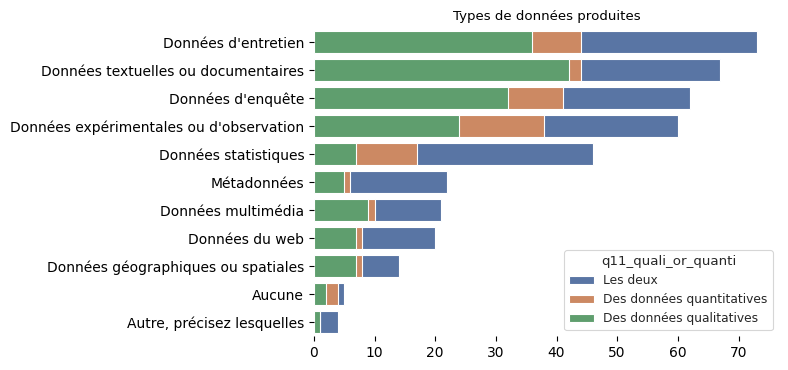

In [20]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_theme(style="ticks", context="paper")

   
g = sns.barplot(x="nb", y="q10_type_data", data=q10, hue="q11_quali_or_quanti", dodge=False)

titre = "Types de données produites"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
#ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))


sns.despine(left=True, bottom=True)
plt.savefig(f"viz/type_donnee_quali.png", bbox_inches='tight', dpi = 200)

## Autres types de données

In [21]:
for x in df0.q10_other_type_data.loc[~df0.q10_other_type_data.isna()]:
    print(x)

Observations in situ non expérimentales
Images
données orales, multimodales et visuo-gestuelles
pourquoi ce terme de "données" hérité des sciences dures et qui ne recoupe pas le travail dans la plupart des humanités ou dont je n'ai pas envie de me servir pour décrire ma recherche + désambiguisez tous les acronymes cf TGIR


### Outils de traitement



In [127]:
i=-1
for x in df_col.label.loc[(df_col.question_family=="q5")& (~df_col.label.str.contains("q5_1"))]:
    i+=1
    gb_data0 = grouped_question(df0, column=x, index = "q45_clé")
    gb_data = gb_data0.loc[gb_data0[x]=="Oui"]
    gb_data.loc[gb_data[x]=="Oui", "logiciel_traitement"] = x.replace("q5_","")
    
    if i == 0:
        gb_q5 = gb_data.drop(columns=[x])#.copy()
    else:
        gb_q5 = pd.concat([gb_q5, gb_data.drop(columns=[x])])
    print(gb_data[[x,"nb","freq"]].to_markdown(index=False))


| q5_r   |   nb |    freq |
|:-------|-----:|--------:|
| Oui    |   38 | 32.4786 |
| q5_python   |   nb |    freq |
|:------------|-----:|--------:|
| Oui         |   22 | 18.8034 |
| q5_excel   |   nb |    freq |
|:-----------|-----:|--------:|
| Oui        |   78 | 66.6667 |
| q5_julia   |   nb |   freq |
|:-----------|-----:|-------:|
| Oui        |    2 | 1.7094 |
| q5_stata   |   nb |   freq |
|:-----------|-----:|-------:|
| Oui        |    4 | 3.4188 |
| q5_sas   |   nb |   freq |
|:---------|-----:|-------:|
| Oui      |    3 | 2.5641 |
| q5_aucun   |   nb |    freq |
|:-----------|-----:|--------:|
| Oui        |   15 | 12.8205 |
| q5_autre   |   nb |    freq |
|:-----------|-----:|--------:|
| Oui        |   36 | 30.7692 |


/tmp/ipykernel_1451/1307973079.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gb_data.loc[gb_data[x]=="Oui", "logiciel_traitement"] = x.replace("q5_","")
/tmp/ipykernel_1451/1307973079.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gb_data.loc[gb_data[x]=="Oui", "logiciel_traitement"] = x.replace("q5_","")
/tmp/ipykernel_1451/1307973079.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [128]:
gb_q5

,nb,total,freq,total_freq,logiciel_traitement
1,38,117,32.478632,100.0,r
1,22,117,18.803419,100.0,python
1,78,117,66.666667,100.0,excel
1,2,117,1.709402,100.0,julia
1,4,117,3.418803,100.0,stata
1,3,117,2.564103,100.0,sas
1,15,117,12.820513,100.0,aucun
1,36,117,30.769231,100.0,autre


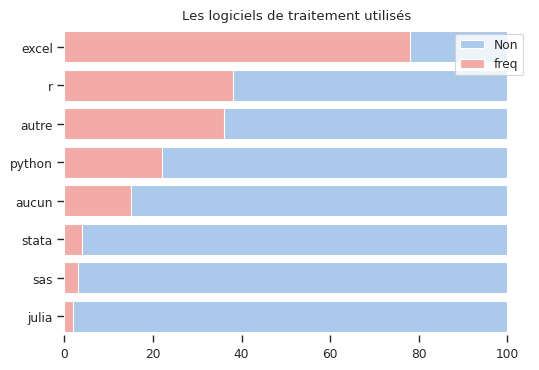

In [130]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,4))

# Plot the total crashes
sns.set_color_codes("pastel")

col = "logiciel_traitement"
sns.barplot(x="total_freq", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="freq", color="r", ax=ax)
titre = "Les logiciels de traitement utilisés"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
plt.savefig(f"viz/logiciel_traitement.png", bbox_inches='tight', dpi = 200)

In [93]:
rec_other_lang ={}
for x in df0.q5_1_other_lang.loc[~df0.q5_1_other_lang.isna()]:
    rec_other_lang[x] = x.lower().replace(", ","|")

rec_other_lang

{'MaxQda, EndNotes, Zotero, ': 'maxqda|endnotes|zotero|',
 '\u200b-': '\u200b-',
 'Matlab': 'matlab',
 'Zotero': 'zotero',
 'LibreOffice Calc': 'libreoffice calc',
 'csv, google sheets': 'csv|google sheets',
 'Jamovi, Iramuteq, Qualcoder': 'jamovi|iramuteq|qualcoder',
 'Nvivo': 'nvivo',
 'php, javascript, d3.js': 'php|javascript|d3.js',
 'Jamovi': 'jamovi',
 'JAMOVI ': 'jamovi ',
 'c#': 'c#',
 'SPSS, Statistica, Jamovi, JASP': 'spss|statistica|jamovi|jasp',
 'Nvivo, IA': 'nvivo|ia',
 'Nvivo et Atlas.ti': 'nvivo et atlas.ti',
 'SPSS': 'spss',
 'OCaml, C, Bash, PHP': 'ocaml|c|bash|php',
 'CSS, html, xml': 'css|html|xml',
 'LaTeX': 'latex',
 'NVivo': 'nvivo',
 'MatLab': 'matlab',
 "QGIS. J'aimerais utiliser Python, mais il faudrait que je sois formée pour en avoir les bases. J'ai déjà suivi la formation de base de R proposée à P8, qui était bien : reste maintenant à se l'approprier !": "qgis. j'aimerais utiliser python|mais il faudrait que je sois formée pour en avoir les bases. j'ai déjà

In [50]:
rec_other_lang = {'MaxQda, EndNotes, Zotero, ': 'maxqda|endnotes|zotero',
 '\u200b-': 'aucun',
 'Matlab': 'matlab',
 'Zotero': 'zotero',
 'LibreOffice Calc': 'libreoffice calc',
 'csv, google sheets': 'csv|google sheets',
 'Jamovi, Iramuteq, Qualcoder': 'jamovi|iramuteq|qualcoder',
 'Nvivo': 'nvivo',
 'php, javascript, d3.js': 'php|javascript|d3.js',
 'Jamovi': 'jamovi',
 'JAMOVI ': 'jamovi',
 'c#': 'c#',
 'SPSS, Statistica, Jamovi, JASP': 'spss|statistica|jamovi|jasp',
 'Nvivo, IA': 'nvivo|ia',
 'Nvivo et Atlas.ti': 'nvivo|atlas.ti',
 'SPSS': 'spss',
 'OCaml, C, Bash, PHP': 'ocaml|c/c++|bash|php',
 'CSS, html, xml': 'css|html|xml',
 'LaTeX': 'latex',
 'NVivo': 'nvivo',
 'MatLab': 'matlab',
 "QGIS. J'aimerais utiliser Python, mais il faudrait que je sois formée pour en avoir les bases. J'ai déjà suivi la formation de base de R proposée à P8, qui était bien : reste maintenant à se l'approprier !": "qgis",
 'Access': 'access',
 'File maker pro': 'file maker pro',
 'LibreOffice Calc, Limesurvey, Grist, ActiveTigger, Neo4j, Gephi': 'libreoffice calc|limesurvey|grist|activetigger|neo4j|gephi',
 'Jamovi, SPSS': 'jamovi|spss',
 'C/C++ Cuda Caml Racket Ludii GDL ASP': 'c/c++|cuda|caml|racket|ludii|gdl|asp',
 'R mais avec Iramutex': 'iramuteq',
 'jamovi': 'jamovi',
 'QSR NVivo': 'nvivo',
 'Mplus, SPSS..': 'mplus|spss'}



df0["q5_1_other_lang_rec"]= df0.q5_1_other_lang.map(rec_other_lang.get)

# on enregistre les nouvelles variables dans le dataframe original
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/anonymous_answer_2026-05-11.csv", "w") as file_out:
    df0.drop(columns=["q5_1_other_lang_family"]).to_csv(file_out, sep=",", index= False)


In [51]:
dic_new_var = {'name':'14. other_lang',
               'label':'q5_1_other_lang_rec',
               'group':'4_logiciel_traitement',
               'personal_data':False,
               'type':'multiple_choice',
               'opened_question':False,
               'type_panda':df0.q5_1_other_lang_rec.dtypes,
               'no_question':14,
               'question':df_col.question.loc[df_col.label=="q5_1_other_lang"].iloc[0],
               "question_family":df_col.question_family.loc[df_col.label=="q5_1_other_lang"].iloc[0],
               'comment':"Recodage de la question 14. mise en basse casse des logiciels cités."
              }
new_variable = pd.DataFrame.from_dict(data=[dic_new_var])
new_variable
df_col = pd.concat([df_col,new_variable], ignore_index = True)
df_col

,name,label,group,personal_data,type,opened_question,type_panda,no_question,question,question_family,comment
0,N°Obs,qno_obs,NaN,False,numérique,False,int64,0.0,NaN,qno,NaN
1,1. so_principles,q1_so_principles,1_connaissance_so,False,ordinal,False,object,1.0,1/ Diriez-vous que vous êtes familier.ère des ...,q1,NaN
2,2. hal_depot,q2_hal_depot,1_connaissance_so,False,ordinal,False,object,2.0,2/ Avez-vous déjà déposé une production scient...,q2,NaN
3,3. octavi_depot,q3_octavi_depot,2_bib_num,False,nominal_multiple,False,object,3.0,3/ Avez-vous des productions déposées sur Octa...,q3,NaN
4,4. open_data,q4_diff_data,3_entrepot,False,nominal_multiple,False,object,4.0,4/ Avez-vous déjà diffusé vos données de reche...,q4,NaN
...,...,...,...,...,...,...,...,...,...,...,...
160,16. dev_exemple,q6_1_rec_exemple,5_developpement,False,simple_nominal,False,object,16.0,"6.1/ Si oui, pourriez-vous expliquer ce que vo...",q6,Recodage de la question 16. Se concentre sur l...
161,16. dev_exemple,q6_1_rec_how,5_developpement,False,simple_nominal,False,object,16.0,"6.1/ Si oui, pourriez-vous expliquer ce que vo...",q6,Recodage de la question 16. Précise si un lang...
162,16. dev_exemple,q6_1_rec_how,5_developpement,False,simple_nominal,False,object,16.0,"6.1/ Si oui, pourriez-vous expliquer ce que vo...",q6,Recodage de la question 16. Restitue le but de...
163,14. other_lang,q5_1_other_lang_rec,4_logiciel_traitement,False,multiple_choice,False,object,14.0,"5.1/ Si Autre, précisez lequel (lesquels) ?",q5,Recodage de la question 14. mise en basse cass...


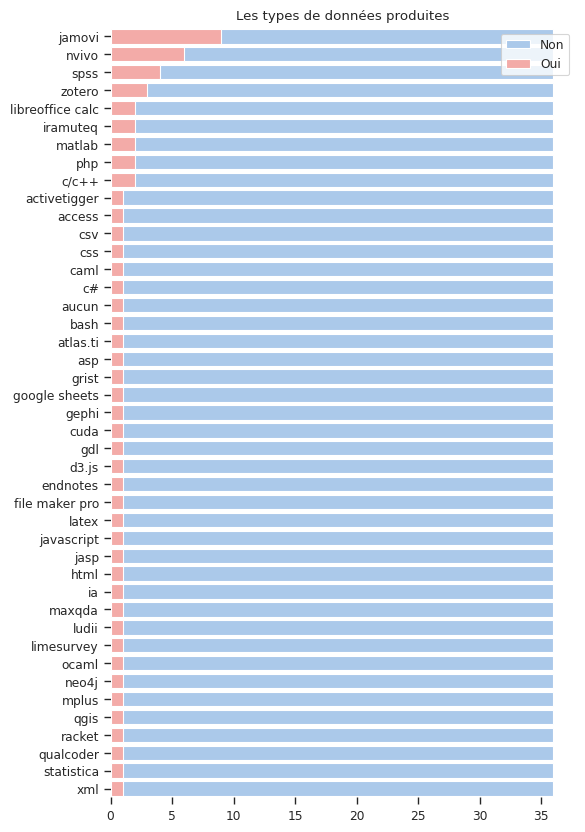

In [52]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,10))

# Plot the total crashes
sns.set_color_codes("pastel")

q5_1 = df0.loc[~df0.q5_1_other_lang_rec.isna()]
col= "q5_1_other_lang_rec"
df_exp, gb_data = split_multiple_choices(q5_1, column=col, index="q45_clé", sep = '|')
sns.barplot(x="total", y=col, data=gb_data,
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_data,
            label="Oui", color="r", ax=ax)
titre = "Les types de données produites"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
#plt.savefig(f"viz/type_donnee.png", bbox_inches='tight', dpi = 200)

In [53]:
list_other_logi = [x for x in df_exp.q5_1_other_lang_rec.unique()]
print(list_other_logi)

['maxqda', 'endnotes', 'zotero', 'aucun', 'matlab', 'libreoffice calc', 'csv', 'google sheets', 'jamovi', 'iramuteq', 'qualcoder', 'nvivo', 'php', 'javascript', 'd3.js', 'c#', 'spss', 'statistica', 'jasp', 'ia', 'atlas.ti', 'ocaml', 'c/c++', 'bash', 'css', 'html', 'xml', 'latex', 'qgis', 'access', 'file maker pro', 'limesurvey', 'grist', 'activetigger', 'neo4j', 'gephi', 'cuda', 'caml', 'racket', 'ludii', 'gdl', 'asp', 'mplus']


In [99]:
family_logi = {'maxqda':'CAQDAS', 
               'endnotes':'gestion biblio', 
               'zotero':'gestion biblio', 
               'aucun':'aucun', 
               'matlab':'script et programmation', 
               'libreoffice calc':'feuille de calcul', 
               'csv':'feuille de calcul', 
               'google sheets':'feuille de calcul',
               'jamovi':'logiciels de stats',
               'iramuteq':'analyse de texte', 
               'qualcoder':'CAQDAS',
               'nvivo':'CAQDAS',
               'php':'développement web', 
               'javascript':'développement web',
               'd3.js':'développement web', 
               'c#':'script et programmation', 
               'spss':'logiciels de stats',
               'statistica':'logiciels de stats',
               'jasp':'logiciels de stats',
               'ia':'ia', 
               'atlas.ti':'CAQDAS',
               'ocaml':'script et programmation', 
               'c/c++':'script et programmation',
               'bash':'script et programmation',
               'css':'développement web',
               'html':'développement web', 
               'xml':'développement web',
               'latex':'script et programmation',
               'qgis':'cartographie',
               'access':'gestion de base de donnée',
               'file maker pro':'gestion de base de donnée',
               'limesurvey':'logiciel d\'enquête statistique',
               'grist':'gestion de base de donnée',
               'activetigger':'analyse de texte',
               'neo4j':'gestion de base de donnée',
               'gephi':'analyse de réseau',
               'cuda':'script et programmation', 
               'caml':'script et programmation', 
               'racket':'script et programmation', 
               'ludii':'création de jeu',
               'gdl':'logiciels de stats',
               'asp':'développement web',
               'mplus': 'logiciels de stats',
               'excel': 'feuille de calcul',
               'python': 'script et programmation',
               'r':'script et programmation',
               'stata':'logiciels de stats',
               'julia': 'script et programmation',
               'sas': 'logiciels de stats'
              }

In [100]:
df01 = df0.copy()

dict_logiciel_traitement = {}
for row in df0.q45_clé:
    logiciel_traitement = []
    for x in df_col.label.loc[(df_col.question_family=="q5")& (~df_col.label.str.contains("q5_1"))]:
        if df01[x].loc[df01.q45_clé==row].values == "Oui":
            logiciel_traitement.append(x.lower().replace("q5_",""))
    if len(logiciel_traitement)>0:
        dict_logiciel_traitement[row]= '|'.join(logiciel_traitement)
df01["q5_logiciel_traitement_rec"] = df01.q45_clé.map(dict_logiciel_traitement)



In [101]:
df0
df_exp, gb_data = split_multiple_choices(df01.loc[~df01.q5_logiciel_traitement_rec.isna()], column='q5_logiciel_traitement_rec', index="q45_clé", sep = '|')
df_exp1, gb_data1 = split_multiple_choices(df01.loc[~df01.q5_1_other_lang_rec.isna()], column='q5_1_other_lang_rec', index="q45_clé", sep = '|')

df_exp2 = pd.concat([df_exp[["q45_clé", 'q5_logiciel_traitement_rec']], df_exp1[["q45_clé","q5_1_other_lang_rec"]].rename(columns={"q5_1_other_lang_rec":'q5_logiciel_traitement_rec'})])
df_exp2["q5_family_logi"]= df_exp2.q5_logiciel_traitement_rec.map(family_logi.get)
df_exp3 = df_exp2.loc[~df_exp2.q5_logiciel_traitement_rec.isin(["aucun","autre"])]
df_exp3

,q45_clé,q5_logiciel_traitement_rec,q5_family_logi
2,FCCB-GMYA,excel,feuille de calcul
3,CV3G-95CT,r,script et programmation
4,M5L8-UM9F,r,script et programmation
4,M5L8-UM9F,excel,feuille de calcul
5,HT8V-PSKZ,python,script et programmation
...,...,...,...
95,7CU7-JG8K,iramuteq,analyse de texte
104,A7R6-3SWC,jamovi,logiciels de stats
111,Q934-QKAW,nvivo,CAQDAS
112,HKN6-95PQ,mplus,logiciels de stats


In [131]:
gb_data = df_exp3.groupby(["q5_family_logi", "q5_logiciel_traitement_rec"]).agg(nb=("q45_clé","size")).sort_values(["q5_family_logi","nb"], ascending=[False,False]).reset_index()



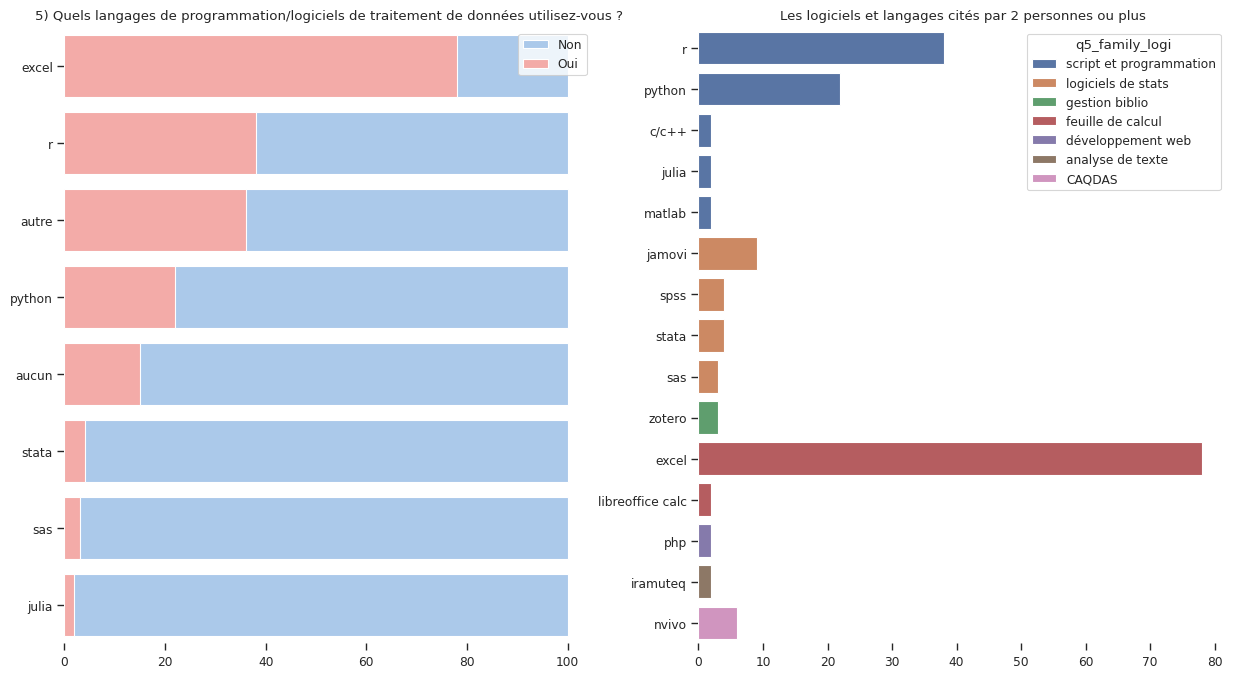

In [138]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, 2, figsize=(15,8))

# Plot the total crashes
sns.set_color_codes("pastel")


col = "logiciel_traitement"
sns.barplot(x="total_freq", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="Non", color="b", ax=ax[0])
sns.barplot(x="nb", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="Oui", color="r", ax=ax[0])
titre = "5) Quels langages de programmation/logiciels de traitement de données utilisez-vous ?"
ax[0].yaxis.set_label_text("")
ax[0].xaxis.set_label_text("")
ax[0].set_title(titre.replace("<i>","(").replace("</i>",")"))

gb_data2 = gb_data.loc[gb_data.nb>1]
sns.barplot(x="nb", y="q5_logiciel_traitement_rec", data=gb_data2,
            hue="q5_family_logi", ax=ax[1])
titre = "Les logiciels et langages cités par 2 personnes ou plus"
ax[1].yaxis.set_label_text("")
ax[1].xaxis.set_label_text("")
ax[1].set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
plt.savefig(f"viz/logiciel_traitement_use_by_2people.png", bbox_inches='tight', dpi = 200)

Le graphique ci-dessous donne à voir les logiciels qui sont cités par plus de deux répondants. Il regroupe les questions 5 et 5.1 sur les logiciels et langages utilisés pour le traitement des données. La question 5 proposait 6 outils : Excel, R, python, SAS, Stata et Julia. Pour chacun de ces outils, les personnes interrogées devaient répondre si elles les utilisaient ou non. Avec la question 5.1, elles pouvaient ensuite compléter leur réponse en donnant le nom d'autres outils informatiques. Les 36 personnes qui ont répondu à la question 5.1 ont ainsi cité 26 autres logiciels et langages, ce qui fait au total 48  outils informatiques différents. Pour faciliter la lecture, nous les avons regroupés par "familles". On retrouve ainsi :

* les "logiciels de statistiques" comme SPSS, Jamovi, Stata ;
* les langages de "scripts et de programmations" comme R, Python, Matlab ou C++. Probablement qu'une subdivision de cette catégorie serait justifiée afin de distinguer les langages généralement employés pour l'analyse de données (R, Julia, Matlab, Python) et les langages de programmation comme C++ ;
* les outils de gestion de bibliographie (Zotero, Endnote) ;
* les logiciels de "tableurs" et les feuilles de calculs : Excel, Libre Calc ;
* les langages liés au développement web (css, html, php, javascript) ;
* les outils d'analyse textuelle (Iramuteq, ActiveTigger) ;
* les "CAQDAS" (Computer-Assisted Qualitative Data Analysis Software) comme Nvivo, Qualcoder, Atlas.ti

En termes d'utilisateurs, Excel est l'outil le plus répendu. Deux tiers des répondants (N=78) y recourent pour traiter leurs données. Ce sont ensuite les langage R (N=38) et Python (N=24) qui sont les plus utilisés. Jamovi (N=9) est le plus cité des logiciels d'analyse statistique, comme Nvivo (N=6) pour les logiciels CAQDAS. On note par ailleurs qu'une peronne sur cinq dit n'utiliser aucun outil informatique pour traiter les données.


![](viz/logiciel_traitement_use_by_2people.png)


In [107]:
df01 = df0.copy()

dict_logiciel_traitement2 = {}
dict_logiciel_fam = {}
for row in df_exp3.q45_clé:
    
    dftmp = df_exp3.loc[df_exp3.q45_clé==row]
    logiciel_traitement2 = [x for x in dftmp.q5_logiciel_traitement_rec.unique()]
    family_logi = [x for x in dftmp.q5_family_logi.unique()]
    dict_logiciel_traitement2[row] = "|".join(logiciel_traitement2)
    dict_logiciel_fam[row] = "|".join(family_logi)


{'FCCB-GMYA': 'feuille de calcul|CAQDAS|gestion biblio',
 'CV3G-95CT': 'script et programmation',
 'M5L8-UM9F': 'script et programmation|feuille de calcul',
 'HT8V-PSKZ': 'script et programmation',
 'R9R6-P7CN': 'feuille de calcul',
 '9K9T-RVNL': 'script et programmation|feuille de calcul',
 'CN6B-UEHQ': 'script et programmation|feuille de calcul',
 '5G5M-BM3L': 'script et programmation|feuille de calcul',
 'BKF8-SNEZ': 'script et programmation',
 'YTMC-B4DP': 'script et programmation|feuille de calcul|logiciels de stats|analyse de texte|CAQDAS',
 'Q5AZ-855W': 'script et programmation|feuille de calcul',
 'QV7Q-KLNA': 'feuille de calcul',
 'ZGPH-2FPH': 'script et programmation|feuille de calcul|développement web',
 'TZYG-EKYM': 'feuille de calcul',
 'ASQY-ZGVK': 'feuille de calcul',
 'MXD6-JC3F': 'feuille de calcul',
 'SKD4-XJMH': 'script et programmation|logiciels de stats',
 'YL4Q-KQAK': 'feuille de calcul',
 '5FJS-YCLW': 'script et programmation|feuille de calcul',
 'RVX8-7FSV': 'fe

In [109]:
df0["q5_logiciel_traitement_rec"]= df0.q45_clé.map(dict_logiciel_traitement2.get)
df0["q5_family_logi"] = df0.q45_clé.map(dict_logiciel_fam.get)


# on enregistre les nouvelles variables dans le dataframe original
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/anonymous_answer_2026-05-11.csv", "w") as file_out:
    df0.drop(columns=["q5_1_other_lang_family"]).to_csv(file_out, sep=",", index= False)


In [110]:
dic_new_var = {'name':'13.1 logiciel de traitment',
               'label':'q5_logiciel_traitement_rec',
               'group':'4_logiciel_traitement',
               'personal_data':False,
               'type':'multiple_choice',
               'opened_question':False,
               'type_panda':df0.q5_logiciel_traitement_rec.dtypes,
               'no_question':5,
               'question':df_col.question.loc[df_col.label=="q5_r"].iloc[0],
               "question_family":df_col.question_family.loc[df_col.label=="q5_r"].iloc[0],
               'comment':"Regroupe les questions 5 et 6 sur les logiciels de traitement"
              }
new_variable = pd.DataFrame.from_dict(data=[dic_new_var])
new_variable
df_col = pd.concat([df_col,new_variable], ignore_index = True)
df_col

dic_new_var = {'name':'13.2 familles de logiciel',
               'label':'q5_family_logi',
               'group':'4_logiciel_traitement',
               'personal_data':False,
               'type':'multiple_choice',
               'opened_question':False,
               'type_panda':df0.q5_family_logi.dtypes,
               'no_question':5,
               'question':df_col.question.loc[df_col.label=="q5_r"].iloc[0],
               "question_family":df_col.question_family.loc[df_col.label=="q5_r"].iloc[0],
               'comment':"Classe les logiciels par famille"
              }
new_variable = pd.DataFrame.from_dict(data=[dic_new_var])
new_variable
df_col = pd.concat([df_col,new_variable], ignore_index = True)
df_col

,name,label,group,personal_data,type,opened_question,type_panda,no_question,question,question_family,comment
0,N°Obs,qno_obs,NaN,False,numérique,False,int64,0.0,NaN,qno,NaN
1,1. so_principles,q1_so_principles,1_connaissance_so,False,ordinal,False,object,1.0,1/ Diriez-vous que vous êtes familier.ère des ...,q1,NaN
2,2. hal_depot,q2_hal_depot,1_connaissance_so,False,ordinal,False,object,2.0,2/ Avez-vous déjà déposé une production scient...,q2,NaN
3,3. octavi_depot,q3_octavi_depot,2_bib_num,False,nominal_multiple,False,object,3.0,3/ Avez-vous des productions déposées sur Octa...,q3,NaN
4,4. open_data,q4_diff_data,3_entrepot,False,nominal_multiple,False,object,4.0,4/ Avez-vous déjà diffusé vos données de reche...,q4,NaN
...,...,...,...,...,...,...,...,...,...,...,...
162,16. dev_exemple,q6_1_rec_how,5_developpement,False,simple_nominal,False,object,16.0,"6.1/ Si oui, pourriez-vous expliquer ce que vo...",q6,Recodage de la question 16. Restitue le but de...
163,14. other_lang,q5_1_other_lang_rec,4_logiciel_traitement,False,multiple_choice,False,object,14.0,"5.1/ Si Autre, précisez lequel (lesquels) ?",q5,Recodage de la question 14. mise en basse cass...
164,14. other_lang,q5_1_other_lang_rec,4_logiciel_traitement,False,multiple_choice,False,object,14.0,"5.1/ Si Autre, précisez lequel (lesquels) ?",q5,Recodage de la question 14. mise en basse cass...
165,13.1 logiciel de traitment,q5_logiciel_traitement_rec,4_logiciel_traitement,False,multiple_choice,False,object,5.0,"5/ Dans le cadre de vos travaux de recherche, ...",q5,Regroupe les questions 5 et 6 sur les logiciel...



### Développement et dépôt de codes ou de logiciels

In [13]:
dev_code= grouped_question(df0, column="q6_dev_code", index = "q45_clé")
print(dev_code)

df_exp, sw_depot2 = split_multiple_choices(df0, column="q7_software_depot", index="q45_clé", sep = '|')
print("\n### Dépôt dans Octaviana détaillé \n", sw_depot2.to_markdown())

  q6_dev_code  nb  total       freq  total_freq
0         Non  86    117  73.504274       100.0
1         Oui  31    117  26.495726       100.0

### Dépôt dans Octaviana détaillé 
 |    | q7_software_depot          |   nb |   total |      freq |   total_freq |
|---:|:---------------------------|-----:|--------:|----------:|-------------:|
|  0 | Non                        |   88 |     117 | 75.2137   |          100 |
|  1 | Oui, sur GitHub            |   22 |     117 | 18.8034   |          100 |
|  2 | Oui, sur GitLab            |   12 |     117 | 10.2564   |          100 |
|  3 | Oui, autre, précisez       |    6 |     117 |  5.12821  |          100 |
|  4 | Oui, sur Software Heritage |    1 |     117 |  0.854701 |          100 |




Près d'un quart des répondants ont déjà été amenés à développer ou faire développer du code ou des logiciels dans le cadre de leurs recherches, dont deux n'ont jamais déposé leur code ou logiciel sur un entrepot dédié.

Si le dépôt de code sur Github et Gitlab restent les solutions les plus usitées, 6 personnes déposent leus codes et logiciels ailleurs : 
* "Sur les dépôts SSC des commandes Stata";
* "sur des repositories personnels";
* "sur Hal";
* "sur Ortolang et Huma-Num",
* "Sur des instances auto-hébergées de Gitlab"
* ou "sur l'INPI".


Les 31 personnes ayant répondu "Oui" à la question "êtes-vous amené.e à développer ou faire développer des logiciels/du code spécialisé(s) ?" ont donnée des précisions sur ce qu'ils développent ou font développer en répondant à la question 16. Nous avons analysé les réponses manuellement et deux profils se dégagent. Le groupe le plus important (N=17) est constitué de chercheurs qui manipulent du code afin de collecter, traiter et analyser les données. Quelques uns (N=4) se distinguent par le fait qu'ils traitent des données issues d'expériences. On a ensuite un ensemble de chercheurs qui développent des "logiciels variés", des "algorithmes" ou encore des "plateformes, programmes logiciels, œuvres" sans données d'autres précisions.



In [44]:
df01.q6_1_rec_groupe.value_counts()


q6_1_rec_groupe
traitement et analyse de données    17
programmes et logiciels variés       8
outils d'expérience                  4
diffusion                            2
Name: count, dtype: int64

In [37]:
rec_code={
    "Mes activités de recherche consist à développer des outils spécialisés pour le traitement de la parole et l'analyse des médias":
    {"what":"traitement du son","group":"traitement et analyse de données", "how":""},
    
    "des apps web": 
    {"what":"applications web","group":"programmes et logiciels variés", "how":""},
    
    "Des logiciels variés, allant du materiel d'expérience à des productions directes à être diffusées.":
    {"what":"outils d'expériences", "group":"programmes et logiciels variés", "how":""},
    
    "Questionnaires et programmes d'expérience sur Psytoolkit":
    {"what":"outils d'expérience","group":"traitement et analyse de données", "how":"PSytooljit"},
    
    "Beaucoup d'outils cf. https://samszo.jardindesconnaissances.fr/HDR/cv/cv.html#sec-item299386":
     {"what":"", "group":"programmes et logiciels variés", "how":""},
    
    "Les Commades Stata":
    {"what":"des commandes stata", "group":"traitement et analyse de données", "how":"Stata"},
    
    "Plugin de moteur temps réel pour la XR.":
    {"what":"plugins pour réalité virtuelle", "group":"programmes et logiciels variés", "how":""},
    
    "Je ne l'ai pas fait moi-même mais à grenoble je travaille avec les ingénieurs de la PUD pour fabriqueur un outil semi automatique de pseudonymisation.":
    {"what":"outils de pseudonymisation", "group": "traitement et analyse de données","how":""},
    
    "Une librairie Julia pour du traitement de réseaux.":
    {"what":"analyse de réseau", "group":"traitement et analyse de données", "how":"Julia"},
    
    "plateformes, programmes logiciels, œuvres":
    {"what":"programmes et logiciels variés", "group":"programmes et logiciels variés", "how":""},
    
    "Logiciels de synthèse et traitement du son":
    {"what":"traitement du son","group":"traitement et analyse de données", "how":""},
    
    "Outil de transcription et d'annotation de données": 
    {"what":"transcription et annotation", "group":"traitement et analyse de données", "how":""},
    
    "https://pablo.rauzy.name/software.html":
    {"what":"", "group":"programmes et logiciels variés","how":""},
    
    "création de site internet pour valorisation et diffusion des activités de recherche, productions des étudiants, etc": 
    {"what":"sites web", "group": "diffusion", "how":""},
    
    "Implémentation d's ou algorithme de démonstration":
    {"what":"implémentation", "group": "programmes et logiciels variés", "how":""},
    
    "jeu sérieux sur tablette": 
    {"what":"jeu sérieux", "group":"outils d'expérience", "how":""},
    
    "Développez les scripts/méthodologies pour traiter mes données":
    {"what":"scripts", "group":"traitement et analyse de données", "how":""},
    
    "Plateforme PatriMaths, sémathèque : https://sematheque.ahp-numerique.fr":
    {"what":"plateforme","group":"diffusion","how":""},
    
    "Dans le cadre du consortium Projets Time Machine, plusieurs logiciels/codes spécialisés sont des logiciels: d'analyse morphologique (MorphAL = Analyse morphologique) qui a énté intégrée comme un plug-in dans QGis ; Amado-on-line (logiciel de visualisation des matrices graphiques le suivant de Bertin)":
    {"what":"analyse morphologique", "group":"traitement et analyse de données", "how":"qgis"},
    
    "prédication de C02 dans Paris":
    {"what":" prédiction", "group":"traitement et analyse de données", "how":""},
    "Scripts Python. En ce moment : prestation avec le CERES pour met à jour Digipower Academy, en partenariat avec l'association suisse Personaldata.io":
    {"what":"applications web", "group":"programmes et logiciels variés","how":"python"},
    
    "jouer aux jeux à 1, à 2 et joueurs et + selon les jeux (ou problèmes considérés)":
    {"what":"jeux", "group":"outils d'expérience", "how":""},
    
    "Des logiciels d'Interaction Humain-Machine transportante des appareils pétéraux d'interactions (recueil de données de protocoles d'interaction)":
    {"what":"logiciels d'interaction humain-machine", "group":"outils d'expérience", "how":""},
    
    "Des cahiers Jupyter pour l'analyse des données de recherche":
    {"what":"notebook", "group":"traitement et analyse de données","how":"jupyter"},
    
    "Nous avons avec l'INA une IA (gpt-oss-120) pour thématiser de gros cormus de vidéos":
    {"what":"classification automatique", "group":"traitement et analyse de données", "how":"IA générative"},
    
    "une série d'outil de modélisation à base d'approche profond lerning":
    {"what":"modélisation",  "group":"traitement et analyse de données", "how":"deep learning"},
    
    "Dans un projet de recherche je participe à participer, nous faisons réaliser un HTR de formulaires manuscrits.":
    {"what":"reconnaissance de caractère", "group":"traitement et analyse de données","how":""},
    
    "des code pour les expériences à l'aide d'outils type PsychToolkit":
    {"what":"outils d'expérience", "group":"outils d'expérience", "how":"psychtoolkit"},
    "TEI/XML adapté à une correspondance du xviiie siècle":
    {"what":"transcription et annotation", "group":"traitement et analyse de données","how":"TEI/XML"},
    
    "Base de de donation TOFLLIT18 (issu d'un projet ANR)":
    {"what":"base de données", "group":"traitement et analyse de données", "how":""},
    
    "des scripts R pour du traitement d'analyse de despageses":
    {"what":"scripts", "group":"traitement et analyse de données", "how":""}
}

In [39]:
list_exemple_code = [x for x in df0.q6_1_dev_exemple.loc[~df0.q6_1_dev_exemple.isna()]]
new_rec_code = {}
for n, x in enumerate(rec_code):
    new_key = list_exemple_code[n]
    new_rec_code[new_key]= rec_code[x]

new_rec_code


{"Mes activités de recherche consiste à développer des outils spécialisés pour le traitement de la parole et l'analyse des médias": {'what': 'traitement du son',
  'group': 'traitement et analyse de données',
  'how': ''},
 'des apps web': {'what': 'applications web',
  'group': 'programmes et logiciels variés',
  'how': ''},
 "Des logiciels variés, allant du materiel d'expérience à des productions directe visant à être diffusées.": {'what': "outils d'expériences",
  'group': 'programmes et logiciels variés',
  'how': ''},
 "Questionnaires et programmes d'expérimentaiton sur Psytoolkit": {'what': "outils d'expérience",
  'group': 'traitement et analyse de données',
  'how': 'PSytooljit'},
 "Beaucoup d'outils cf. https://samszo.jardindesconnaissances.fr/HDR/cv/cv.html#sec-item299386": {'what': '',
  'group': 'programmes et logiciels variés',
  'how': ''},
 'Des commades Stata': {'what': 'des commandes stata',
  'group': 'traitement et analyse de données',
  'how': 'Stata'},
 'Plugin de 

In [41]:
list_row= []
for x in new_rec_code:

    id_row = df0.q45_clé.loc[df0.q6_1_dev_exemple==x].values

    if len(id_row) > 0:
        exemple = new_rec_code[x]
        dict_row = {"q45_clé":id_row[0],
              "q6_1_rec_exemple":exemple["what"].lower(),
              "q6_1_rec_groupe":exemple["group"].lower(),
              "q6_1_rec_how": exemple["how"].lower()}
        list_row.append(dict_row)

dftp = pd.DataFrame.from_dict(list_row)
dftp


Mes activités de recherche consiste à développer des outils spécialisés pour le traitement de la parole et l'analyse des médias
['CN6B-UEHQ'] 1
des apps web
['5G5M-BM3L'] 1
Des logiciels variés, allant du materiel d'expérience à des productions directe visant à être diffusées.
['BKF8-SNEZ'] 1
Questionnaires et programmes d'expérimentaiton sur Psytoolkit
['YTMC-B4DP'] 1
Beaucoup d'outils cf. https://samszo.jardindesconnaissances.fr/HDR/cv/cv.html#sec-item299386
['ZGPH-2FPH'] 1
Des commades Stata
['SKD4-XJMH'] 1
Plugin de moteur temps réel pour la XR.
['RVX8-7FSV'] 1
Je ne l'ai pas fait moi-même mais à grenoble je travaille avec les ingénieurs de la PUD pour fabriquer un outil semi automatique de pseudonymisation.
['E3YL-PHZV'] 1
Une librairie Julia pour du traitement de réseaux.
['RAUZ-BRFQ'] 1
plateformes logiciel, programmes, oeuvres
['QH7Q-PJZ9'] 1
Logiciels de synthèse et traitement du son
['Q3YA-587D'] 1
Outil de transcription et d'annotation de données
['6454-S2QM'] 1
https://pabl

,q45_clé,q6_1_rec_exemple,q6_1_rec_groupe,q6_1_rec_how
0,CN6B-UEHQ,traitement du son,traitement et analyse de données,
1,5G5M-BM3L,applications web,programmes et logiciels variés,
2,BKF8-SNEZ,outils d'expériences,programmes et logiciels variés,
3,YTMC-B4DP,outils d'expérience,traitement et analyse de données,psytooljit
4,ZGPH-2FPH,,programmes et logiciels variés,
5,SKD4-XJMH,des commandes stata,traitement et analyse de données,stata
6,RVX8-7FSV,plugins pour réalité virtuelle,programmes et logiciels variés,
7,E3YL-PHZV,outils de pseudonymisation,traitement et analyse de données,
8,RAUZ-BRFQ,analyse de réseau,traitement et analyse de données,julia
9,QH7Q-PJZ9,programmes et logiciels variés,programmes et logiciels variés,


In [42]:


df01 = df0.drop(columns=['q6_1_rec_exemple', 'q6_1_rec_groupe',
       'q6_1_rec_how', 'q6_1_rec_exemple', 'q6_1_rec_groupe',
       'q6_1_rec_how']).merge(dftp, on = ["q45_clé"], how="left")




df01

,qno_obs,q1_so_principles,q2_hal_depot,q3_octavi_depot,q4_diff_data,q4_autres_entrepots,q5_r,q5_python,q5_excel,q5_julia,...,q54_appareil_utilisé_pour_la_saisie,q25_statut_rec,q25_doctorant,q3_octavi_rec,q4_autres_entrepots_rec,q4_diff_data_grouped,q4_diff_data_rec,q6_1_rec_exemple,q6_1_rec_groupe,q6_1_rec_how
0,1,"Oui, un peu","Oui, une fois",Non,Non,NaN,Non,Non,Non,Non,...,PC,Doctorant,True,Non,NaN,Non,Non,NaN,NaN,NaN
1,2,"Oui, un peu","Oui, une fois",Non,Non,NaN,Non,Non,Non,Non,...,PC,Chercheur,False,Non,NaN,Non,Non,NaN,NaN,NaN
2,3,"Oui, tout à fait","Oui, plusieurs fois",Je ne connais pas Octaviana,Non,NaN,Non,Non,Oui,Non,...,PC,Chercheur,False,Non,NaN,Non,Non,NaN,NaN,NaN
3,4,"Oui, un peu","Oui, une fois",Non,"Autre, précisez",OSF,Oui,Non,Non,Non,...,PC,Chercheur,False,Non,osf,Oui,osf,NaN,NaN,NaN
4,6,"Oui, un peu","Oui, systématiquement",Non;Je ne connais pas Octaviana,Non,NaN,Oui,Non,Oui,Non,...,PC,Chercheur,False,Non,NaN,Non,Non,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,115,"Oui, tout à fait","Oui, plusieurs fois",Non,"Autre, précisez",osf,Oui,Oui,Non,Non,...,PC,Chercheur,False,Non,osf,Oui,osf,NaN,NaN,NaN
113,116,"Oui, tout à fait","Oui, plusieurs fois",Non,"Oui, sur Zenodo, Nakala",NaN,Non,Non,Oui,Non,...,PC,Chercheur,False,Non,NaN,Oui,"Oui, sur Zenodo, Nakala",base de données,traitement et analyse de données,
114,117,"Oui, un peu","Oui, plusieurs fois",Non,"Autre, précisez",OSF,Oui,Oui,Oui,Non,...,PC,Doctorant,True,Non,osf,Oui,osf,NaN,NaN,NaN
115,118,"Oui, un peu","Oui, systématiquement",Non,Non,NaN,Oui,Non,Oui,Non,...,PC,Chercheur,False,Non,NaN,Non,Non,NaN,NaN,NaN


In [43]:
# on enregistre les nouvelles variables dans le dataframe original
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/anonymous_answer_2026-05-11.csv", "w") as file_out:
    df01.to_csv(file_out, sep=",", index= False)

In [ ]:
dic_new_var = {'name':'16. dev_exemple',
               'label':'q6_1_rec_how',
               'group':'5_developpement',
               'personal_data':False,
               'type':'simple_nominal',
               'opened_question':False,
               'type_panda':df01.q6_1_rec_groupe.dtypes,
               'no_question':16,
               'question':df_col.question.loc[df_col.label=="q6_1_dev_exemple"].iloc[0],
               'comment':"Recodage de la question 16. Restitue le but des logiciels développés : analyse de données, diffusion, etc."
              }
new_variable = pd.DataFrame.from_dict(data=[dic_new_var])
new_variable
df_col = pd.concat([df_col,new_variable], ignore_index = True)
df_col

In [ ]:
df_col.to_csv("../le_questionnaire/dico_variable.csv", sep=",", index= False)



## Les besoins d'accompagnement à la Science Ouverte

Mis à part l'accompagnement au dépot dans Hal, une majorité de répondants juge les accompagnement à la Science Ouverte comme étant utiles. Les licences de diffusion des résultats de recherche est le sujet pour lequel les répondants ont manifesté le plus d'intérêt : 87% considèrent qu'un accompagnement sur ce thème serait "plutôt utile" (52%) voire "très utile" (35%). Vient ensuite la "fairisation" des données de recherche avec 81% des participants à l'enquêtre déclarant qu'il serait utile d'être accompagner dan sle processus permettant de produire des données respectant les principes FAIR : Facile à trouver, Accessible, Interopérable, et Réutilisable. De façon général, les accompagnements apparaissent d'autant plus utiles qu'ils portent sur des aspects juridiques (licence, RGPD) ou des sujets liés à l'ouverture des données (métadonnées, dépots, principes FAIR).

![](viz/util_accomp_so.png)


In [35]:
for col in df_col.label.loc[(df_col.group=="6_help_SO")&(df_col.type=="ordinal")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q8_depot_hal_help   |   nb |   total |     freq |   total_freq |
|---:|:--------------------|-----:|--------:|---------:|-------------:|
|  0 | Non, pas utile      |   81 |     117 | 69.2308  |          100 |
|  1 | Oui, plutôt utile   |   25 |     117 | 21.3675  |          100 |
|  2 | Oui, très utile     |   11 |     117 |  9.40171 |          100 |
|    | q8_rediger_pdg_help   |   nb |   total |    freq |   total_freq |
|---:|:----------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile        |   43 |     117 | 36.7521 |          100 |
|  1 | Oui, plutôt utile     |   46 |     117 | 39.3162 |          100 |
|  2 | Oui, très utile       |   28 |     117 | 23.9316 |          100 |
|    | q8_respect_rgpd_help   |   nb |   total |    freq |   total_freq |
|---:|:-----------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile         |   40 |     117 | 34.188  |          100 |
|  1 | Oui, plutôt utile      |   50 |     117 | 42.7

In [36]:
[col for col in df_col.label.loc[(df_col.group=="6_help_SO")&(df_col.type=="ordinal")]]

['q8_depot_hal_help',
 'q8_rediger_pdg_help',
 'q8_respect_rgpd_help',
 'q8_licences_help',
 'q8_depot_donnees_help',
 'q8_metadonnees_help',
 'q8_data_paper_help',
 'q8_fair_data_help']

In [37]:
dict_accomp = {'q8_depot_hal_help':"Dépot sur Hal",
 'q8_rediger_pdg_help': 'Rédiger un PGD',
 'q8_respect_rgpd_help': 'Respecter le RGPD',
 'q8_licences_help': 'Choix des licences de diffusion',
 'q8_depot_donnees_help': 'Déposer des données',
 'q8_metadonnees_help': 'Connaître les standards de métadonnées',
 'q8_data_paper_help':'Rédiger un data paper',
 'q8_fair_data_help':'Fairiser les données'
              }

In [38]:

i=-1
for col in df_col.label.loc[(df_col.group=="6_help_SO")&(df_col.type=="ordinal")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"interet_accomp"})
    dftmp["accomp_name"]= dict_accomp[col]


    if i == 0:
        q8 = dftmp.copy()
    else:
        q8 = pd.concat([q8, dftmp])


In [39]:
q8_dis = pd.crosstab(q8.accomp_name, q8.interet_accomp, normalize="index").cumsum(axis=1).stack().reset_index(name='nb').sort_values(by=["accomp_name","interet_accomp"],
                                                                                                                                     ascending=[True, False])


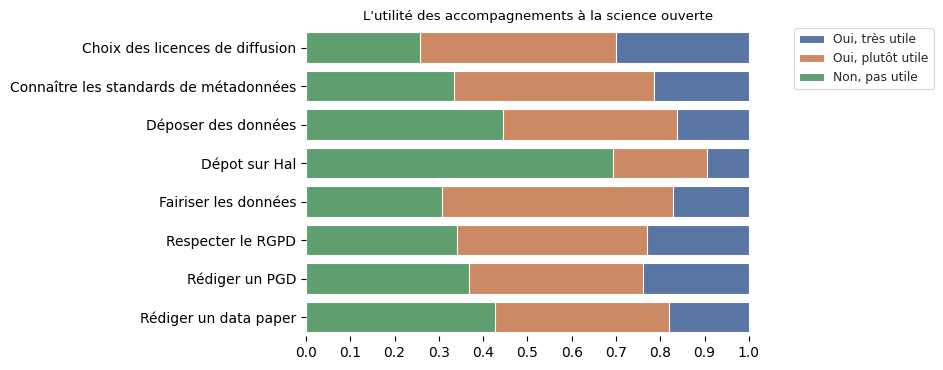

In [40]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_theme(style="ticks", context="paper")

   
g = sns.barplot(x="nb", y="accomp_name", data=q8_dis, hue="interet_accomp", dodge=False)

titre = "L'utilité des accompagnements à la science ouverte"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
ax.legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

sns.despine(left=True, bottom=True)
plt.savefig(f"viz/util_accomp_so.png", bbox_inches='tight', dpi = 200)

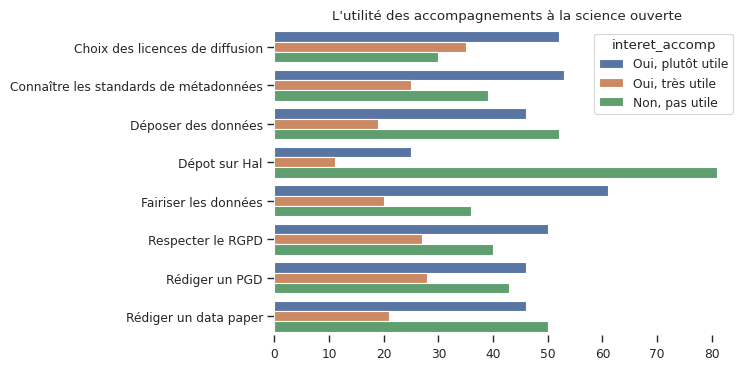

In [41]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_color_codes("pastel")

q8_grp = q8.groupby(["accomp_name","interet_accomp"]).agg(nb=("q45_clé", "size")).sort_values(by=["accomp_name","nb"], ascending=[True, False])

    
sns.barplot(x="nb", y="accomp_name", data=q8_grp, hue="interet_accomp", dodge=True)
titre = "L'utilité des accompagnements à la science ouverte"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
#plt.savefig(f"viz/autre_entrepot_rec.png", bbox_inches='tight', dpi = 200)

# Types de données

In [ ]:
#%%capture cap
for n, family in enumerate(df_col.question_family.unique()):
    list_quest = [x for x in dict_question if dict_question[x]==family]
    if len(list_quest) > 0:
        question = df_col.question.loc[df_col.question_family == family].iloc[0]
        print("==================\n", question)
        for m, col in enumerate(list_quest):
            print(df_col.name.loc[df_col.label==col].iloc[0])
            gb_data = grouped_question(df0, column=col, index = "q45_clé")
            print(gb_data)
            print("---------------------\n")
            
        


In [ ]:
with open("tableau_frequence_question_simple.txt", 'w') as file_in:
    file_in.write(cap.stdout)

In [ ]:
def tab_croise(data, x, y, regroup_y = True, khideux = False) :
    """
    x = variable en ligne
    y = variable en colonne
    """
    if regroup_y == True:

        data.loc[data[y].str.lower().str.contains("oui"), f"{y}_rec"] = "Oui"
        data.loc[data[y].str.lower().str.contains("non"), f"{y}_rec"] = "Non"

        cross_tab = pd.crosstab(data[x], data[f"{y}_rec"], margins = True, margins_name="Total", normalize=False)
        cross_tab0 = pd.crosstab(data[x], data[f"{y}_rec"], margins = False)
    else:
        cross_tab = pd.crosstab(data[x], data[y], margins = True, margins_name="Total", normalize=False)
        cross_tab0 = pd.crosstab(data[x], data[f"{y}_rec"], margins = False)

    if khideux == True:
        print(scipy.stats.chi2_contingency(cross_tab0))
        st_chi2, st_p, st_dof, st_exp = scipy.stats.chi2_contingency(cross_tab0)
        chi2 = pd.DataFrame(data={"stats":["chi2","df","p-value"], "values":[st_chi2, st_dof, st_p]})
        cross_tab = pd.concat([cross_tab, chi2])
    else:
        pass

    return cross_tab.fillna("").reset_index()

In [ ]:
tab_croise(df0, x= "q25_statut_rec", y="q2_hal_depot", regroup_y = True, khideux = True)

In [ ]:
(15*107)/119

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
list_family = [x for x in dict_question.values()]
list_family_dedup = []
for x in list_family:
    if list_family_dedup.count(x) == 0:
        list_family_dedup.append(x)
    else:
        pass


In [ ]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(len(list_family), figsize=(10, 30))

# Plot the total crashes
sns.set_color_codes("pastel")

for n, family in enumerate(df_col.question_family.unique()):
    list_quest = [x for x in dict_question if dict_question[x]==family]
    if len(list_quest) > 0:
        for m, col in enumerate(list_quest):
            #print(col)
            gb_data = grouped_question(df0, column=col, index = "q45_clé")
        
            sns.barplot(x="freq", hue=col, data=gb_data, ax=ax[n])

       

In [ ]:
sns.barplot(x="nb", y=col, data=gb_data,
                label="effectif", color="r", ax=ax[n])